<a href="https://colab.research.google.com/github/jowu-brunonian/For-Funsies/blob/main/Data_Model_Martial_Hero_A_Limited_Edition_Wuxia_Fantasy_Anthology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import pandas as pd

# Initialize lists to store the parsed data
data = []

# Manually parse the provided data points
# June 8, 2026, Monday
data.append({'Date': '2026-06-08', 'Time': None, 'Followers': 201, 'Backers': None, 'Funding_USD': None, 'Event': 'Day before live'})
data.append({'Date': '2026-06-08', 'Time': None, 'Followers': 203, 'Backers': None, 'Funding_USD': None, 'Event': 'Day before live'})

# June 9, 2026, Tuesday
data.append({'Date': '2026-06-09', 'Time': '09:04', 'Followers': None, 'Backers': None, 'Funding_USD': None, 'Event': 'Kickstarter went live'})
data.append({'Date': '2026-06-09', 'Time': None, 'Followers': None, 'Backers': 21, 'Funding_USD': 1000, 'Event': 'Hit goal in 13 min'})
data.append({'Date': '2026-06-09', 'Time': None, 'Followers': None, 'Backers': 39, 'Funding_USD': None, 'Event': None})
data.append({'Date': '2026-06-09', 'Time': None, 'Followers': None, 'Backers': 49, 'Funding_USD': None, 'Event': None})
data.append({'Date': '2026-06-09', 'Time': None, 'Followers': None, 'Backers': None, 'Funding_USD': 3000, 'Event': '$3k reached'})
data.append({'Date': '2026-06-09', 'Time': '12:34', 'Followers': None, 'Backers': 75, 'Funding_USD': 3250, 'Event': None})
data.append({'Date': '2026-06-09', 'Time': '15:50', 'Followers': None, 'Backers': 91, 'Funding_USD': None, 'Event': None})
data.append({'Date': '2026-06-09', 'Time': '18:25', 'Followers': None, 'Backers': 104, 'Funding_USD': 4385, 'Event': None})
data.append({'Date': '2026-06-09', 'Time': '20:37', 'Followers': None, 'Backers': 114, 'Funding_USD': 4860, 'Event': None})
data.append({'Date': '2026-06-09', 'Time': '21:00', 'Followers': None, 'Backers': 118, 'Funding_USD': 5455, 'Event': None})

# June 10, 2026 Wednesday
data.append({'Date': '2026-06-10', 'Time': '15:00', 'Followers': None, 'Backers': None, 'Funding_USD': 7000, 'Event': 'Got over $7000'})

# June 11, 2026 Thursday
data.append({'Date': '2026-06-11', 'Time': '08:42', 'Followers': None, 'Backers': 153, 'Funding_USD': 7530, 'Event': None})

df = pd.DataFrame(data)
display(df)

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Date,Time,Followers,Backers,Funding_USD,Event
0,2026-06-08,None,201.0,NaN,NaN,Day before live
1,2026-06-08,None,203.0,NaN,NaN,Day before live
2,2026-06-09,09:04,NaN,NaN,NaN,Kickstarter went live
3,2026-06-09,None,NaN,21.0,1000.0,Hit goal in 13 min
4,2026-06-09,None,NaN,39.0,NaN,None
5,2026-06-09,None,NaN,49.0,NaN,None
6,2026-06-09,None,NaN,NaN,3000.0,$3k reached
7,2026-06-09,12:34,NaN,75.0,3250.0,None
8,2026-06-09,15:50,NaN,91.0,NaN,None
9,2026-06-09,18:25,NaN,104.0,4385.0,None


In [52]:
import numpy as np
import pandas as pd # Ensure pandas is imported if this cell can be run standalone

# Re-create df from the raw data list to ensure 'Date' and 'Time' columns exist
# This assumes the 'data' list from the previous cell is still in memory.
df = pd.DataFrame(data)

# Combine 'Date' and 'Time' into a single datetime column
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'].fillna('00:00'))

# Sort the DataFrame by DateTime
df = df.sort_values(by='DateTime').reset_index(drop=True)

# Fill missing values for Followers, Backers, and Funding_USD using forward-fill
# First, ensure these columns are numeric, coercing errors will turn non-numeric into NaN
df['Followers'] = pd.to_numeric(df['Followers'], errors='coerce')
df['Backers'] = pd.to_numeric(df['Backers'], errors='coerce')
df['Funding_USD'] = pd.to_numeric(df['Funding_USD'], errors='coerce')

# Now, forward-fill the NaN values. For Followers, Backers, and Funding, they are cumulative, so ffill is appropriate.
df['Followers'] = df['Followers'].ffill()
df['Backers'] = df['Backers'].ffill()
df['Funding_USD'] = df['Funding_USD'].ffill()

# Set DateTime as index for time series analysis
df = df.set_index('DateTime')

# Drop the original 'Date' and 'Time' columns if no longer needed
df = df.drop(columns=['Date', 'Time'])

display(df)

,Followers,Backers,Funding_USD,Event
DateTime,,,,
2026-06-08 00:00:00,201.0,NaN,NaN,Day before live
2026-06-08 00:00:00,203.0,NaN,NaN,Day before live
2026-06-09 00:00:00,203.0,21.0,1000.0,Hit goal in 13 min
2026-06-09 00:00:00,203.0,39.0,1000.0,None
2026-06-09 00:00:00,203.0,49.0,1000.0,None
2026-06-09 00:00:00,203.0,49.0,3000.0,$3k reached
2026-06-09 09:04:00,203.0,49.0,3000.0,Kickstarter went live
2026-06-09 12:34:00,203.0,75.0,3250.0,None
2026-06-09 15:50:00,203.0,91.0,3250.0,None


In [53]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# Fill initial NaN values for 'Backers' and 'Funding_USD' with 0
df['Backers'] = df['Backers'].fillna(0)
df['Funding_USD'] = df['Funding_USD'].fillna(0)

# Re-apply ffill after filling initial NaNs, in case there are internal NaNs
df['Followers'] = df['Followers'].ffill()
df['Backers'] = df['Backers'].ffill()
df['Funding_USD'] = df['Funding_USD'].ffill()

# Filter out entries before the Kickstarter went live (June 9, 2026 09:04AM)
df_kickstarter_live = df[df.index >= '2026-06-09 09:04:00'].copy()

# Resample to daily frequency, taking the last value of each day
df_daily = df_kickstarter_live.resample('D').last()

# Drop any rows where all 'Followers', 'Backers', and 'Funding_USD' are NaN after resampling (e.g., future dates with no data)
df_daily = df_daily.dropna(subset=['Followers', 'Backers', 'Funding_USD'], how='all')

# Forward fill any NaNs that might have been created by resampling (e.g., if a day had no updates)
df_daily['Followers'] = df_daily['Followers'].ffill()
df_daily['Backers'] = df_daily['Backers'].ffill()
df_daily['Funding_USD'] = df_daily['Funding_USD'].ffill()

# Create a 'Day_Number' feature for the current data
# We'll use the first date in df_daily as the starting point (Day 0)
start_date = df_daily.index.min()
df_daily['Day_Number'] = (df_daily.index - start_date).days

# Prepare the data for the linear regression model
X = df_daily[['Day_Number']]
y = df_daily['Funding_USD']

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X, y)

print("Linear Regression Model trained successfully.")
print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_[0]}")

Linear Regression Model trained successfully.
Intercept: 5624.166666666668
Coefficient: 1037.4999999999995


In [54]:
import numpy as np
import pandas as pd

# Generate future dates for the next 15 days
last_day_number = df_daily['Day_Number'].max()
future_day_numbers = np.arange(last_day_number + 1, last_day_number + 1 + 15).reshape(-1, 1)

# --- Conservative Funding Prediction ---
# Instead of using the linear regression model directly,
# we'll assume a more conservative, fixed daily increase after the last historical value.
last_funding_value = df_daily['Funding_USD'].iloc[-1]
conservative_daily_increment = 100 # A conservative estimate for daily growth during a 'dead zone'

# Calculate conservative future funding predictions
future_predictions_conservative = [last_funding_value + (i + 1) * conservative_daily_increment for i in range(len(future_day_numbers))]

# Create a DataFrame for future predictions
future_dates = pd.date_range(start=df_daily.index.max() + pd.Timedelta(days=1), periods=15, freq='D')
df_future_predictions = pd.DataFrame({
    'Day_Number': future_day_numbers.flatten(),
    'Funding_USD': future_predictions_conservative # Use the conservative predictions
}, index=future_dates)

# Combine historical and predicted data for plotting
df_combined = pd.concat([df_daily[['Funding_USD', 'Day_Number']], df_future_predictions])

display(df_combined.tail(20)) # Display last few historical and all predicted values

,Funding_USD,Day_Number
2026-06-09,5455.0,0
2026-06-10,7000.0,1
2026-06-11,7530.0,2
2026-06-12,7630.0,3
2026-06-13,7730.0,4
2026-06-14,7830.0,5
2026-06-15,7930.0,6
2026-06-16,8030.0,7
2026-06-17,8130.0,8
2026-06-18,8230.0,9


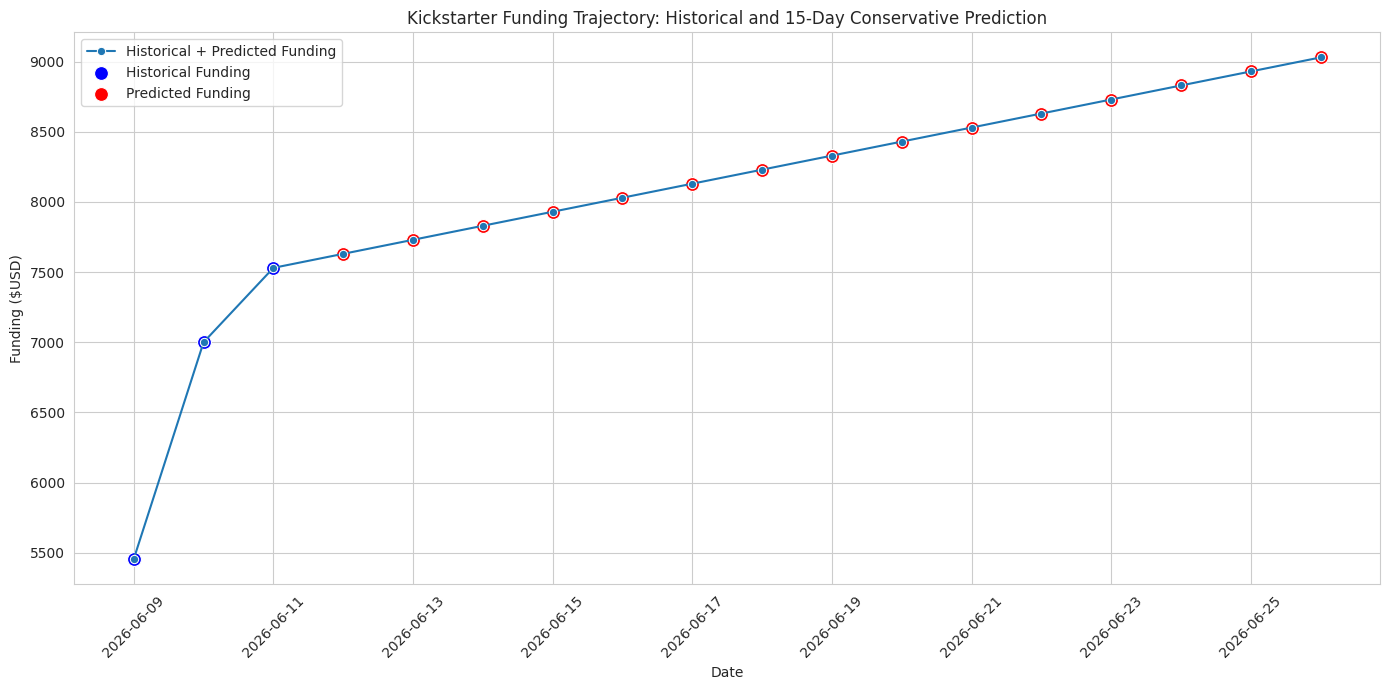

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(14, 7))
sns.lineplot(x=df_combined.index, y='Funding_USD', data=df_combined, marker='o', label='Historical + Predicted Funding')

# Highlight historical data points
sns.scatterplot(x=df_daily.index, y='Funding_USD', data=df_daily, color='blue', s=100, label='Historical Funding')

# Highlight predicted data points
sns.scatterplot(x=df_future_predictions.index, y='Funding_USD', data=df_future_predictions, color='red', s=100, label='Predicted Funding')

plt.title('Kickstarter Funding Trajectory: Historical and 15-Day Conservative Prediction')
plt.xlabel('Date')
plt.ylabel('Funding ($USD)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Prediction Summary

Based on the linear regression model, here are the predicted funding values for the next 15 days:


### Actual Funding and Backers

Actual funding received: **$16,338**
Actual backers: **334**

In [56]:
actual_funding = 16338
actual_backers = 334

# Get the last predicted funding value
last_predicted_funding = df_future_predictions['Funding_USD'].iloc[-1]

# Calculate the difference
funding_difference = actual_funding - last_predicted_funding

print(f"Last predicted funding: ${last_predicted_funding:.2f}")
print(f"Actual funding: ${actual_funding:.2f}")
print(f"Difference (Actual - Predicted): ${funding_difference:.2f}")

# You can also compare the predicted backers if you had a model for them
# For now, let's just display the actual backers in context.
print(f"Actual backers: {actual_backers}")

Last predicted funding: $9030.00
Actual funding: $16338.00
Difference (Actual - Predicted): $7308.00
Actual backers: 334


In [57]:
# Define the date for the final actual values
# Let's place it a couple of days after the last prediction (June 26) to show the end result clearly.
actual_final_date = pd.Timestamp('2026-06-28')

# Create a DataFrame for the actual funding point
df_actual_final_funding = pd.DataFrame({
    'Funding_USD': [actual_funding]
}, index=[actual_final_date])

# Create a DataFrame for the actual backers point
df_actual_final_backers = pd.DataFrame({
    'Followers': [actual_backers] # Using 'Followers' column name for consistency with plot
}, index=[actual_final_date])

/tmp/ipykernel_2918/4037919315.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Type', y='Value', data=df_funding_chart, palette=['skyblue', 'lightcoral'])


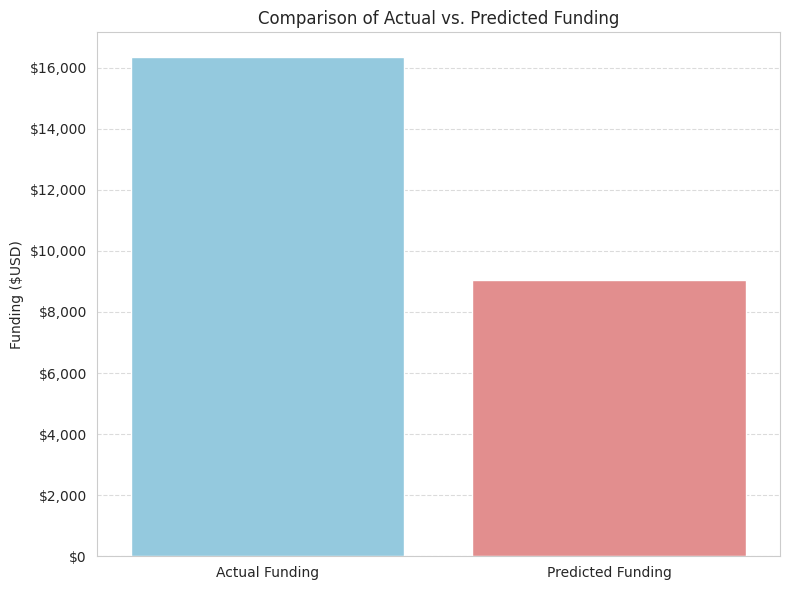

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported for DataFrame creation

sns.set_style("whitegrid")

# Data for Funding Chart
funding_data = {
    'Type': ['Actual Funding', 'Predicted Funding'],
    'Value': [actual_funding, last_predicted_funding]
}
df_funding_chart = pd.DataFrame(funding_data)

plt.figure(figsize=(8, 6))
sns.barplot(x='Type', y='Value', data=df_funding_chart, palette=['skyblue', 'lightcoral'])
plt.title('Comparison of Actual vs. Predicted Funding')
plt.ylabel('Funding ($USD)')
plt.xlabel('')
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Format y-axis as currency
formatter = plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2918/3536732529.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Type', y='Value', data=df_followers_backers_chart, palette=['skyblue', 'lightcoral'])


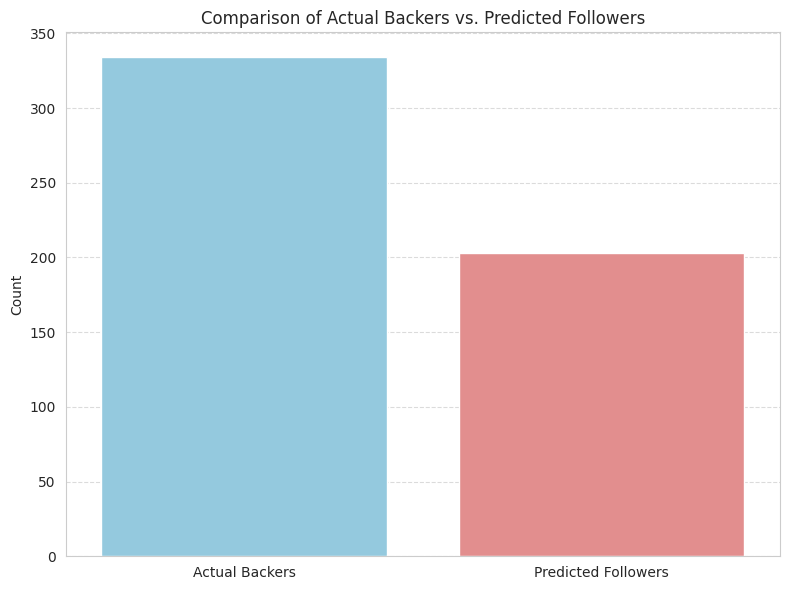

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported for DataFrame creation

sns.set_style("whitegrid")

# Data for Followers/Backers Chart
followers_backers_data = {
    'Type': ['Actual Backers', 'Predicted Followers'],
    'Value': [actual_backers, last_predicted_followers]
}
df_followers_backers_chart = pd.DataFrame(followers_backers_data)

plt.figure(figsize=(8, 6))
sns.barplot(x='Type', y='Value', data=df_followers_backers_chart, palette=['skyblue', 'lightcoral'])
plt.title('Comparison of Actual Backers vs. Predicted Followers')
plt.ylabel('Count')
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [60]:
display(df_future_predictions[['Funding_USD']])

,Funding_USD
2026-06-12,7630.0
2026-06-13,7730.0
2026-06-14,7830.0
2026-06-15,7930.0
2026-06-16,8030.0
2026-06-17,8130.0
2026-06-18,8230.0
2026-06-19,8330.0
2026-06-20,8430.0
2026-06-21,8530.0


In [61]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare the data for the linear regression model for followers
X_followers = df_daily[['Day_Number']]
y_followers = df_daily['Followers']

# Initialize and train the Linear Regression model for followers
model_followers = LinearRegression()
model_followers.fit(X_followers, y_followers)

print("Linear Regression Model for Followers trained successfully.")
print(f"Intercept for Followers: {model_followers.intercept_}")
print(f"Coefficient for Followers: {model_followers.coef_[0]}")

Linear Regression Model for Followers trained successfully.
Intercept for Followers: 203.0
Coefficient for Followers: 0.0


In [62]:
# Generate future day numbers for prediction (same as for funding)
last_day_number = df_daily['Day_Number'].max()
future_day_numbers_followers = np.arange(last_day_number + 1, last_day_number + 1 + 15).reshape(-1, 1)

# Predict followers for these future days
future_follower_predictions = model_followers.predict(future_day_numbers_followers)

# Create a DataFrame for future follower predictions
future_dates_followers = pd.date_range(start=df_daily.index.max() + pd.Timedelta(days=1), periods=15, freq='D')
df_future_follower_predictions = pd.DataFrame({
    'Day_Number': future_day_numbers_followers.flatten(),
    'Followers': future_follower_predictions
}, index=future_dates_followers)

# Combine historical and predicted follower data for plotting
df_combined_followers = pd.concat([df_daily[['Followers', 'Day_Number']], df_future_follower_predictions])

display(df_combined_followers.tail(20)) # Display last few historical and all predicted values

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Followers,Day_Number
2026-06-09,203.0,0
2026-06-10,203.0,1
2026-06-11,203.0,2
2026-06-12,203.0,3
2026-06-13,203.0,4
2026-06-14,203.0,5
2026-06-15,203.0,6
2026-06-16,203.0,7
2026-06-17,203.0,8
2026-06-18,203.0,9


### Follower Prediction Summary

Based on the linear regression model, here are the predicted follower values for the next 15 days:


In [63]:
display(df_future_follower_predictions[['Followers']])

,Followers
2026-06-12,203.0
2026-06-13,203.0
2026-06-14,203.0
2026-06-15,203.0
2026-06-16,203.0
2026-06-17,203.0
2026-06-18,203.0
2026-06-19,203.0
2026-06-20,203.0
2026-06-21,203.0


In [64]:
# Fill initial NaN values for 'Backers' and 'Funding_USD' with 0
df['Backers'] = df['Backers'].fillna(0)
df['Funding_USD'] = df['Funding_USD'].fillna(0)

# Re-apply ffill after filling initial NaNs, in case there are internal NaNs
df['Followers'] = df['Followers'].ffill()
df['Backers'] = df['Backers'].ffill()
df['Funding_USD'] = df['Funding_USD'].ffill()

# Filter out entries before the Kickstarter went live (June 9, 2026 09:04AM)
df_kickstarter_live = df[df.index >= '2026-06-09 09:04:00'].copy()

# Resample to daily frequency, taking the last value of each day
df_daily = df_kickstarter_live.resample('D').last()

# Drop any rows where all 'Followers', 'Backers', and 'Funding_USD' are NaN after resampling (e.g., future dates with no data)
df_daily = df_daily.dropna(subset=['Followers', 'Backers', 'Funding_USD'], how='all')

# Forward fill any NaNs that might have been created by resampling (e.g., if a day had no updates)
df_daily['Followers'] = df_daily['Followers'].ffill()
df_daily['Backers'] = df_daily['Backers'].ffill()
df_daily['Funding_USD'] = df_daily['Funding_USD'].ffill()

# Display the cleaned and resampled daily data
display(df_daily)


,Followers,Backers,Funding_USD,Event
DateTime,,,,
2026-06-09,203.0,118.0,5455.0,Kickstarter went live
2026-06-10,203.0,118.0,7000.0,Got over $7000
2026-06-11,203.0,153.0,7530.0,None


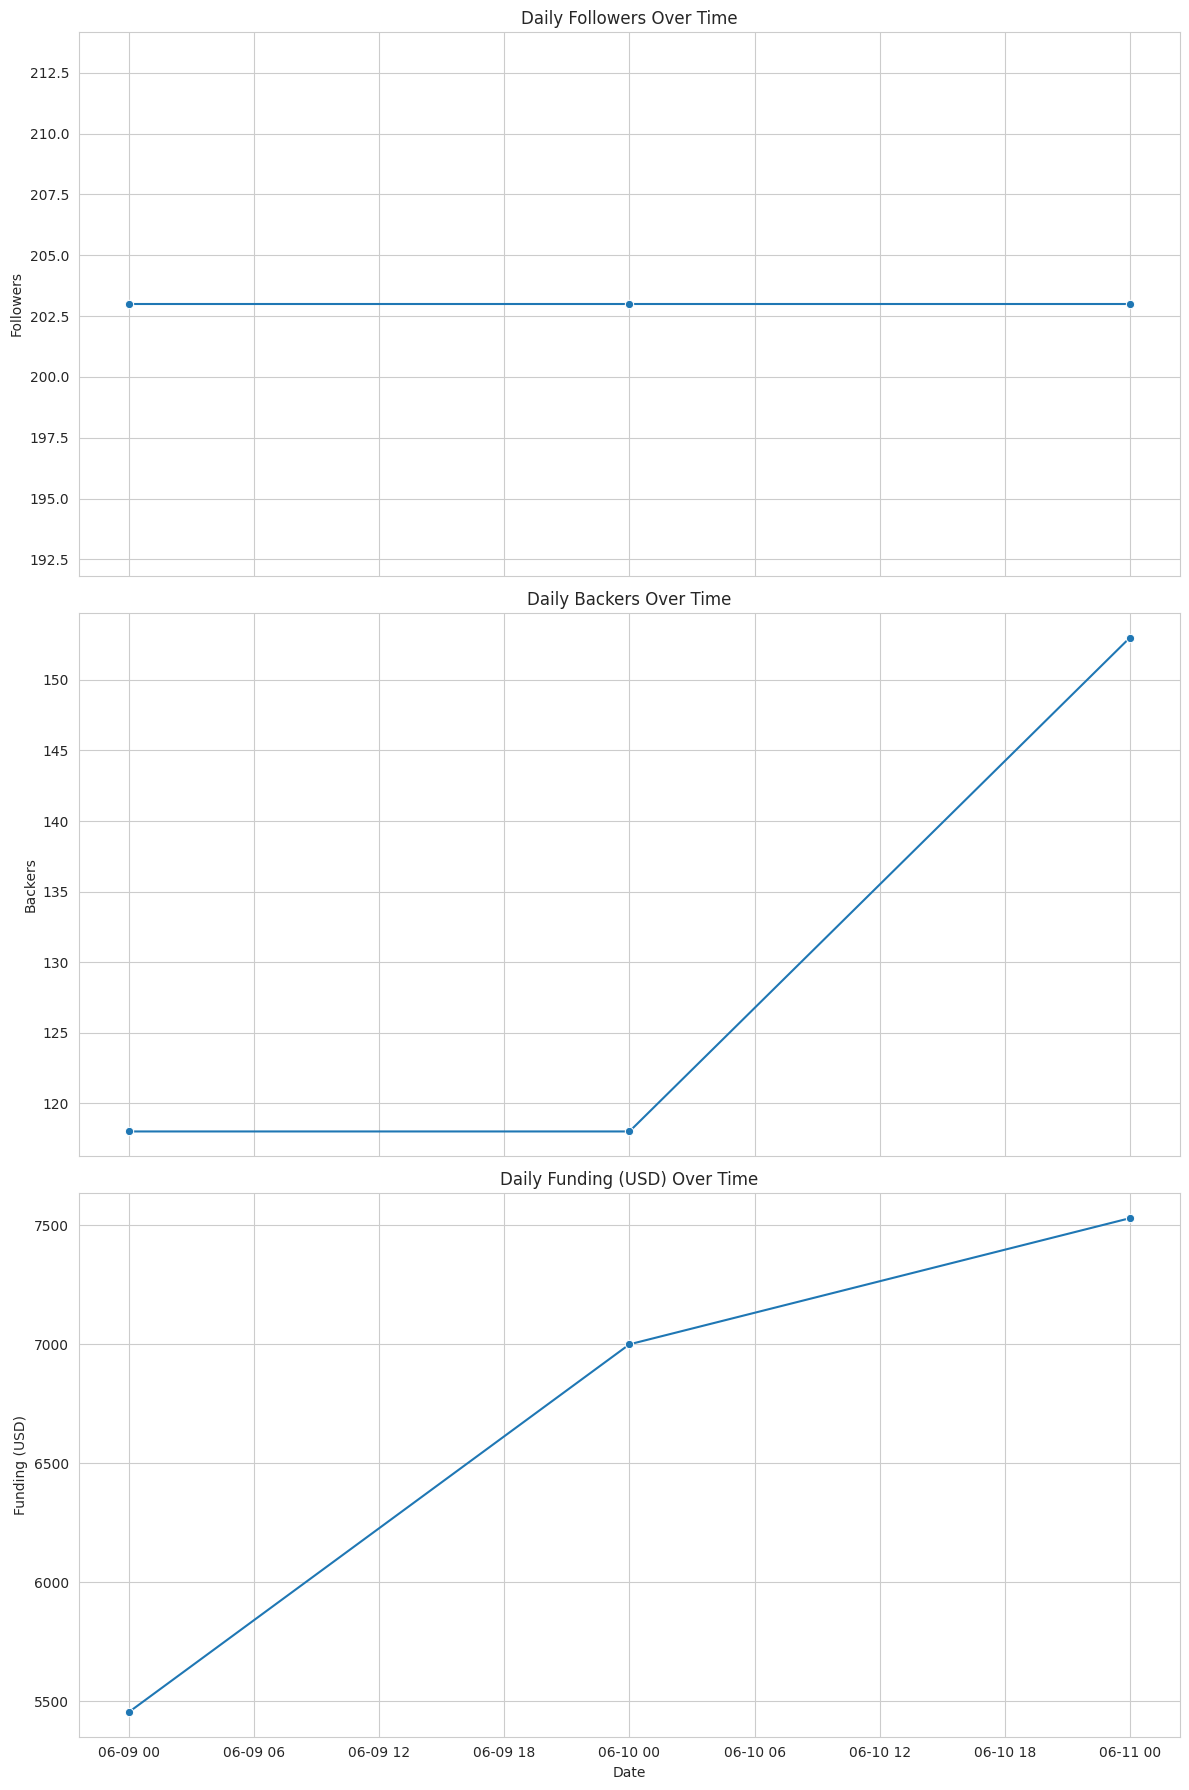

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Create subplots for each metric
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 18), sharex=True)

# Plot Followers over time
sns.lineplot(ax=axes[0], x=df_daily.index, y='Followers', data=df_daily, marker='o')
axes[0].set_title('Daily Followers Over Time')
axes[0].set_ylabel('Followers')

# Plot Backers over time
sns.lineplot(ax=axes[1], x=df_daily.index, y='Backers', data=df_daily, marker='o')
axes[1].set_title('Daily Backers Over Time')
axes[1].set_ylabel('Backers')

# Plot Funding_USD over time
sns.lineplot(ax=axes[2], x=df_daily.index, y='Funding_USD', data=df_daily, marker='o')
axes[2].set_title('Daily Funding (USD) Over Time')
axes[2].set_ylabel('Funding (USD)')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

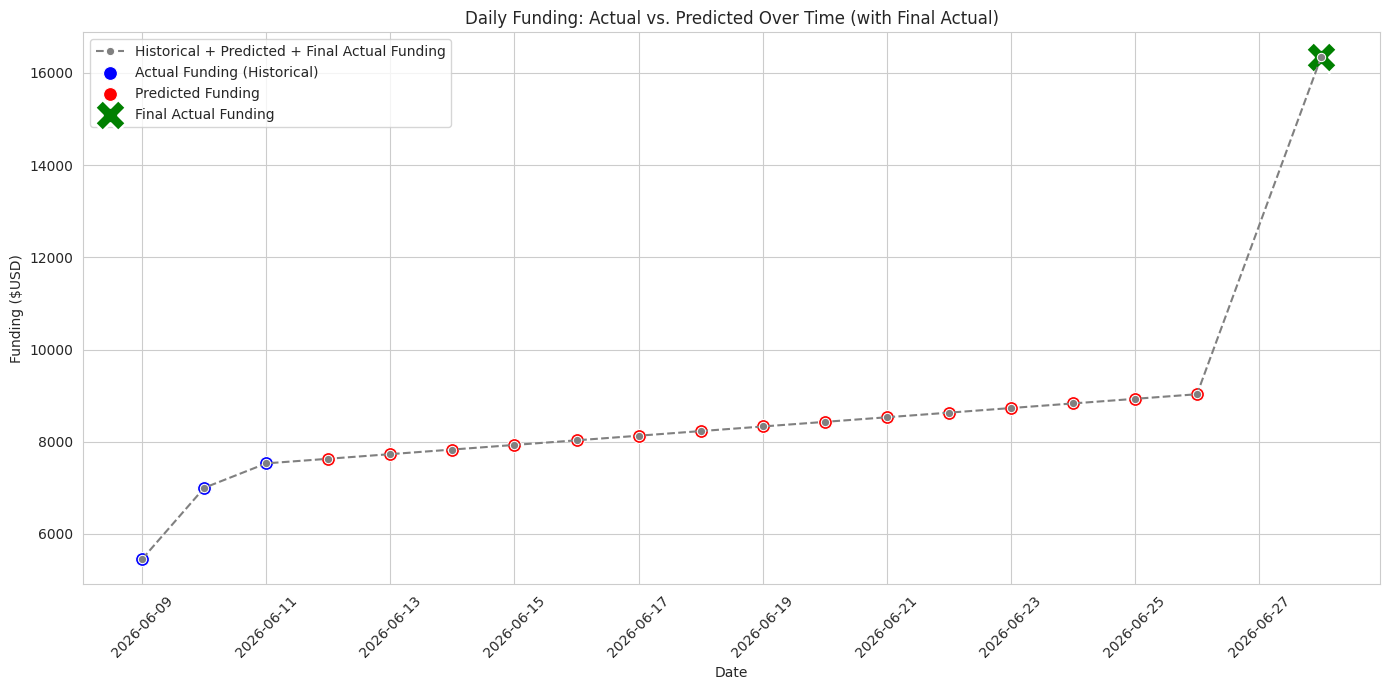

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Combine historical, predicted, and final actual funding for the line plot
df_combined_with_final_funding = pd.concat([df_combined, df_actual_final_funding]).sort_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x=df_combined_with_final_funding.index, y='Funding_USD', data=df_combined_with_final_funding, marker='o', label='Historical + Predicted + Final Actual Funding', color='gray', linestyle='--')

# Highlight historical data points
sns.scatterplot(x=df_daily.index, y='Funding_USD', data=df_daily, color='blue', s=100, label='Actual Funding (Historical)')

# Highlight predicted data points
sns.scatterplot(x=df_future_predictions.index, y='Funding_USD', data=df_future_predictions, color='red', s=100, label='Predicted Funding')

# Add the final actual funding point with a MUCH larger marker
sns.scatterplot(x=df_actual_final_funding.index, y='Funding_USD', data=df_actual_final_funding, color='green', s=500, marker='X', label='Final Actual Funding')

plt.title('Daily Funding: Actual vs. Predicted Over Time (with Final Actual)')
plt.xlabel('Date')
plt.ylabel('Funding ($USD)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

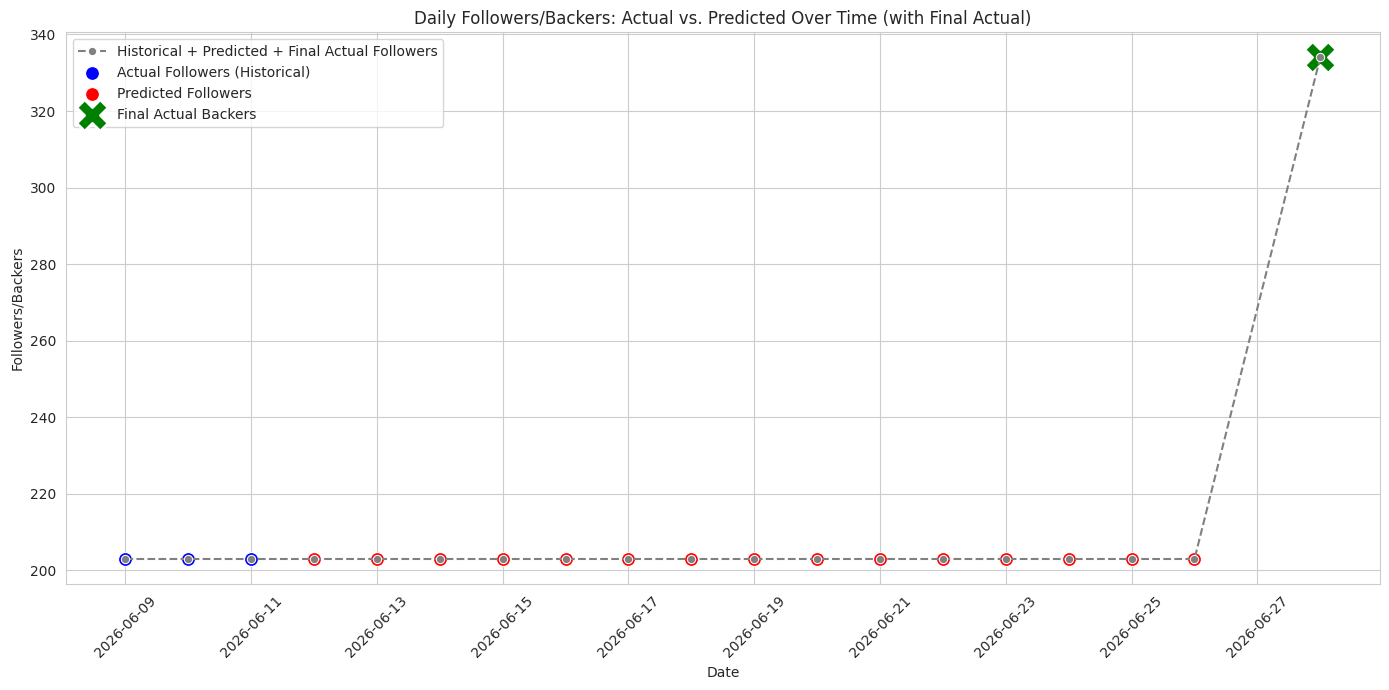

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Combine historical, predicted, and final actual backers for the line plot
df_combined_with_final_followers = pd.concat([df_combined_followers, df_actual_final_backers]).sort_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x=df_combined_with_final_followers.index, y='Followers', data=df_combined_with_final_followers, marker='o', label='Historical + Predicted + Final Actual Followers', color='gray', linestyle='--')

# Highlight historical data points (actual backers/followers)
sns.scatterplot(x=df_daily.index, y='Followers', data=df_daily, color='blue', s=100, label='Actual Followers (Historical)')

# Highlight predicted data points
sns.scatterplot(x=df_future_follower_predictions.index, y='Followers', data=df_future_follower_predictions, color='red', s=100, label='Predicted Followers')

# Add the final actual backers point with a MUCH larger marker
sns.scatterplot(x=df_actual_final_backers.index, y='Followers', data=df_actual_final_backers, color='green', s=500, marker='X', label='Final Actual Backers')

plt.title('Daily Followers/Backers: Actual vs. Predicted Over Time (with Final Actual)')
plt.xlabel('Date')
plt.ylabel('Followers/Backers')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [71]:
df_daily.to_csv('kickstarter_daily_data.csv', index=True)
print('Data saved to kickstarter_daily_data.csv')


Data saved to kickstarter_daily_data.csv
